In [32]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape (scaled):", X_train_scaled.shape)
print("Testing set shape (scaled):", X_test_scaled.shape)

Training set shape (scaled): (105, 4)
Testing set shape (scaled): (45, 4)


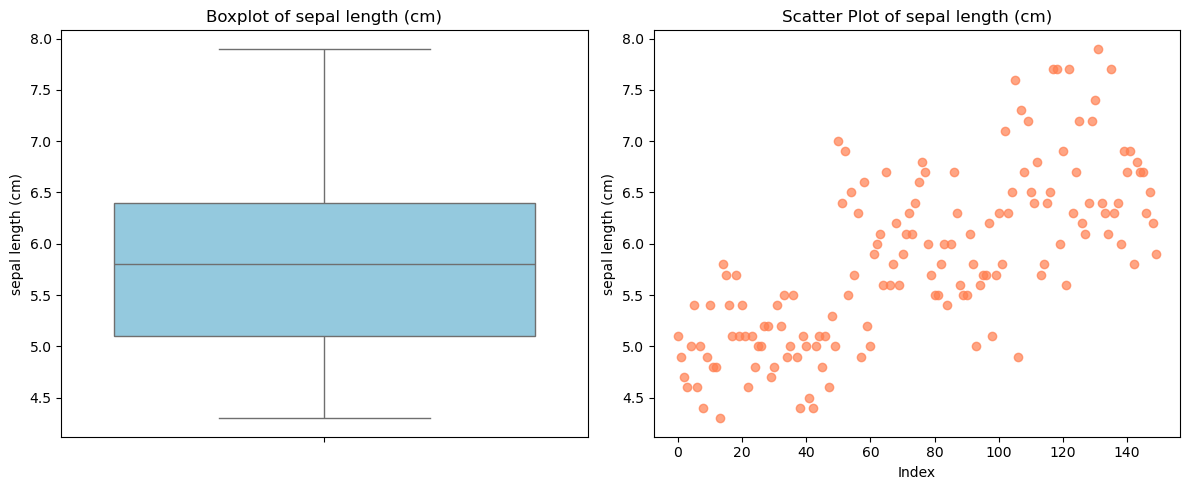

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris


def plot_boxplot_and_scatter(df: pd.DataFrame, column_name: str) -> None:
    """Plots a Boxplot and a Scatter plot for a given column in a DataFrame."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Boxplot
    sns.boxplot(y=df[column_name], ax=axes[0], color="skyblue")
    axes[0].set_title(f"Boxplot of {column_name}")
    axes[0].set_ylabel(column_name)

    # Scatter plot
    axes[1].scatter(df.index, df[column_name], alpha=0.7, color="coral")
    axes[1].set_title(f"Scatter Plot of {column_name}")
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel(column_name)

    plt.tight_layout()
    plt.show()


# --- ADD THESE LINES TO RUN THE FUNCTION ---
iris = load_iris(as_frame=True)
df_iris = iris.frame
plot_boxplot_and_scatter(df_iris, "sepal length (cm)")

In [34]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


In [35]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Predicted classes for test dataset:\n", y_pred)

Predicted classes for test dataset:
 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


Confusion Matrix:
 [[ 57   6]
 [  1 107]]


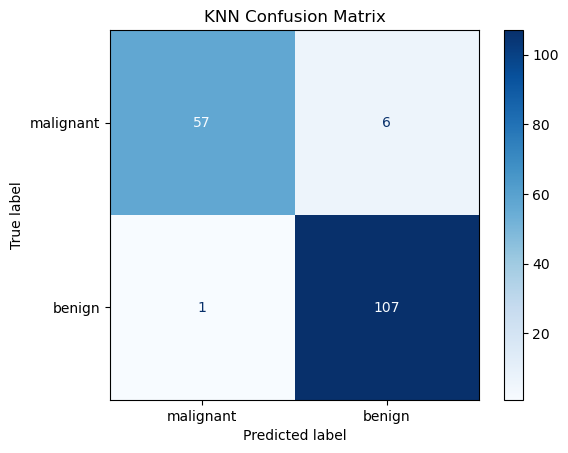

In [36]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=data.target_names
)
disp.plot(cmap=plt.cm.Blues)
plt.title("KNN Confusion Matrix")
plt.show()

In [37]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = make_classification(
    n_samples=1000, n_features=20, n_classes=2, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Decision Tree Accuracy:  {dt_acc * 100:.2f}%")
print(f"Random Forest Accuracy:  {rf_acc * 100:.2f}%")

if rf_acc > dt_acc:
    print("Result: Random Forest performed better.")
elif dt_acc > rf_acc:
    print("Result: Decision Tree performed better.")
else:
    print("Result: Both models performed equally well.")

Decision Tree Accuracy:  85.67%
Random Forest Accuracy:  85.67%
Result: Both models performed equally well.


In [38]:
from sklearn.metrics import f1_score, precision_score, recall_score

y_true = [0, 1, 1, 0, 1, 0, 1, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1, 0, 1, 1, 1, 1]

target_pos_label = 1

precision = precision_score(y_true, y_pred, pos_label=target_pos_label)
recall = recall_score(y_true, y_pred, pos_label=target_pos_label)
f1 = f1_score(y_true, y_pred, pos_label=target_pos_label)

print(f"Metrics for Target Class ({target_pos_label}):")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Metrics for Target Class (1):
Precision: 0.8333
Recall:    0.8333
F1-Score:  0.8333


In [39]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

X, y = fetch_california_housing(return_X_y=True)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = Ridge(alpha=1.0)

scores = cross_val_score(
    ridge, X, y, cv=kf, scoring="neg_root_mean_squared_error"
)
rmse_scores = -scores

print(f"5-Fold RMSE Scores: {rmse_scores}")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f}")
print(f"Standard Deviation of RMSE: {np.std(rmse_scores):.4f}")

5-Fold RMSE Scores: [0.74552228 0.72640228 0.71365563 0.71054941 0.74509773]
Mean RMSE: 0.7282
Standard Deviation of RMSE: 0.0149


In [40]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Optimal Hyperparameters:", grid_search.best_params_)
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Optimal Hyperparameters: {'max_depth': None, 'n_estimators': 200}
Best Cross-Validation Score: 0.9626


In [41]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

pipeline = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("classifier", LogisticRegression(max_iter=200)),
    ]
)

pipeline.fit(X_train, y_train)
test_accuracy = pipeline.score(X_test, y_test)
print(f"Pipeline Test Accuracy: {test_accuracy * 100:.2f}%")

Pipeline Test Accuracy: 91.11%
